Imports: PyTorch, torchvision, matplotlib.

InpaintCNN:

Encoder: downsamples with convolution + pooling.

Decoder: upsamples to reconstruct missing regions.

Dataset: CIFAR‑10, only 200 images, auto‑downloaded, 80–20 split.

Masking: Zeroes out the center region of each image (simulated missing patch).

Loss: MSELoss ensures output resembles original unmasked image.

Training: Runs 5 epochs, prints average loss.

Visualization:

Row 1: Original images

Row 2: Masked input images

Row 3: Reconstructed (inpainted) outputs

100%|██████████| 170M/170M [00:01<00:00, 101MB/s]


Epoch 1, Loss: 0.0561
Epoch 2, Loss: 0.0356
Epoch 3, Loss: 0.0297
Epoch 4, Loss: 0.0257
Epoch 5, Loss: 0.0227
Training complete!


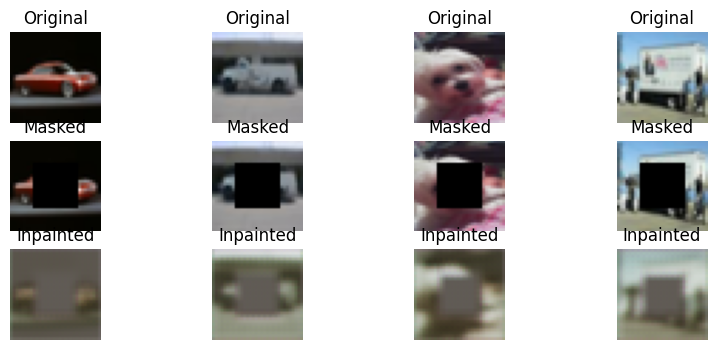

In [ ]:
"""
Experiment 5: Image Editing and Inpainting using Python & PyTorch
-----------------------------------------------------------------
This program demonstrates a simple inpainting technique where missing
parts of an image are filled in using a lightweight CNN.
Dataset: CIFAR-10 (200 images, auto-downloaded, 80-20 split).
"""

# Step 1: Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Step 2: Define a simple CNN Inpainting Model
class InpaintCNN(nn.Module):
    def __init__(self):
        super(InpaintCNN, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2), nn.ReLU(),
            nn.Conv2d(32, 3, 3, padding=1), nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Step 3: Load CIFAR-10 dataset (200 samples only)
transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])
full_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
subset_indices = list(range(200))   # limit to 200 images
small_dataset = Subset(full_dataset, subset_indices)

# Split 80-20
train_size = int(0.8 * len(small_dataset))
test_size = len(small_dataset) - train_size
train_set, test_set = random_split(small_dataset, [train_size, test_size])

trainloader = DataLoader(train_set, batch_size=8, shuffle=True)
testloader = DataLoader(test_set, batch_size=8, shuffle=False)

# Step 4: Create model, loss, optimizer
model = InpaintCNN()
criterion = nn.MSELoss()   # Pixel reconstruction loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Step 5: Training loop (5 epochs)
for epoch in range(5):
    model.train()
    running_loss = 0.0
    for images, _ in trainloader:
        # Create masked images (simulate missing region)
        masked_images = images.clone()
        masked_images[:,:,8:24,8:24] = 0   # black square in center

        optimizer.zero_grad()
        outputs = model(masked_images)
        loss = criterion(outputs, images)  # reconstruct original image
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}")

print("Training complete!")

# Step 6: Evaluate and visualize inpainting
model.eval()
images, _ = next(iter(testloader))
masked_images = images.clone()
masked_images[:,:,8:24,8:24] = 0

with torch.no_grad():
    outputs = model(masked_images)

# Plot original, masked, and reconstructed
plt.figure(figsize=(10,4))
for i in range(4):
    plt.subplot(3,4,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3,4,i+5)
    plt.imshow(masked_images[i].permute(1,2,0))
    plt.title("Masked")
    plt.axis("off")

    plt.subplot(3,4,i+9)
    plt.imshow(outputs[i].permute(1,2,0))
    plt.title("Inpainted")
    plt.axis("off")
plt.show()
